In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("synthetic_applicants.csv")
df.head()


,app_id,income,dti,age,bureau_score,new_to_credit,recent_arrears,utilisation,hardship_flag,segment
0,1,33079.0,0.266,28,529.0,0,0,0.527,0,Value
1,2,20661.0,0.240,31,655.0,0,0,0.581,0,Core
2,3,38664.0,0.372,30,646.0,0,0,1.038,0,Core
3,4,41324.0,0.350,36,688.0,0,1,0.552,0,Value
4,5,15020.0,0.151,31,711.0,0,0,0.791,0,Value


# Layer 1 — Applicant Rules

In [3]:
df["rule_applicant"] = "pass"

# low inocme / high DTI  → affordability decline
df.loc[df["income"] < 25000, "rule_applicant"] = "decline_affordability"
df.loc[df["dti"] > 0.55, "rule_applicant"] = "decline_affordability"

# extremely low bureau score → risk decline
df.loc[df["bureau_score"] < 500, "rule_applicant"] = "decline_risk"

df["rule_applicant"].value_counts()


rule_applicant
pass                     1320
decline_affordability     678
decline_risk                2
Name: count, dtype: int64

# Layer 2 — Behaviour Rule

In [5]:
df["rule_behaviour"] = "pass"

df.loc[df["recent_arrears"] == 1, "rule_behaviour"] = "refer_review"
df.loc[df["utilisation"] > 0.95, "rule_behaviour"] = "refer_review"
df.loc[df["hardship_flag"] == 1, "rule_behaviour"] = "refer_review"

df["rule_behaviour"].value_counts()


rule_behaviour
pass            1684
refer_review     316
Name: count, dtype: int64

# Layer 3 - Policy Rules (Based on segment)

In [17]:
df["rule_policy"] = "pass"

# HighRisk segment，higher bureau_score
df.loc[(df["segment"] == "HighRisk") & (df["bureau_score"] < 580),
       "rule_policy"] = "decline_policy"

# Value segment，higher tolerance
df.loc[(df["segment"] == "Value") & (df["bureau_score"] < 540),
       "rule_policy"] = "decline_policy"

df["rule_policy"].value_counts()


rule_policy
pass              1986
decline_policy      14
Name: count, dtype: int64

# Final Decision

In [7]:
def final_decision(row):
    # Check applicant-level decline
    if row["rule_applicant"].startswith("decline"):
        return "decline"
    # Check policy-level decline
    if row["rule_policy"].startswith("decline"):
        return "decline"
    # Check behaviour refer
    if row["rule_behaviour"].startswith("refer"):
        return "refer"
    # approve
    return "approve"

df["decision"] = df.apply(final_decision, axis=1)
df["decision"].value_counts(normalize=True).round(3)



decision
approve    0.550
decline    0.344
refer      0.106
Name: proportion, dtype: float64

In [9]:
df.to_csv("merged_data.csv", index=False)


# Summary & Visualisation

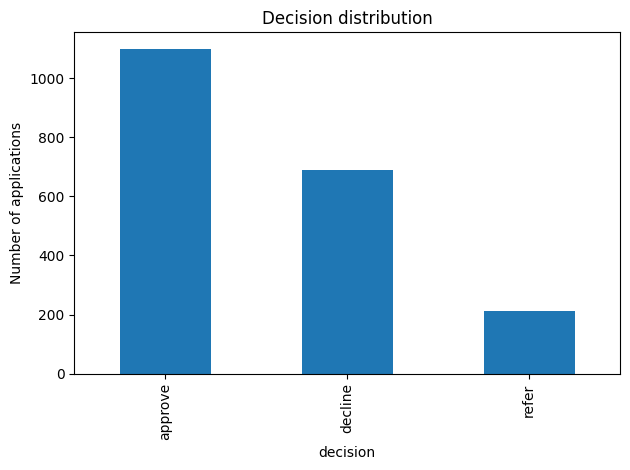

In [14]:
df = pd.read_csv("merged_data.csv")

decision_counts = df["decision"].value_counts().reindex(["approve","decline","refer"])

decision_counts.plot(kind="bar")
plt.ylabel("Number of applications")
plt.title("Decision distribution")
plt.tight_layout()
plt.show()
plt.savefig("decision_distribution.png", dpi=150)
plt.close()


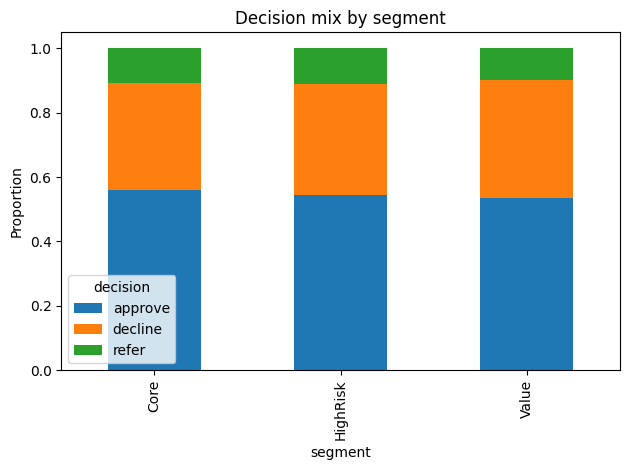

In [15]:
seg_table = pd.crosstab(df["segment"], df["decision"], normalize="index").round(3)
seg_table

seg_table.to_csv("segment_impact_table.csv")

seg_table.plot(kind="bar", stacked=True)
plt.ylabel("Proportion")
plt.title("Decision mix by segment")
plt.tight_layout()
plt.show()
plt.savefig("segment_mix_by_segment.png", dpi=150)
plt.close()


# Export to Excel

In [16]:
with pd.ExcelWriter("approval_decline_summary.xlsx") as writer:
    decision_counts.to_frame("count").to_excel(writer, sheet_name="Overall_decisions")
    seg_table.to_excel(writer, sheet_name="By_segment")